# FFT Analysis — worked examples

The companion notebook to the [FFT Analysis
manual](../../docs/manuals/fft-analysis.md). Same five examples, same demo
files, same numbers — computed here in a few lines of `spwb.processing`
instead of clicked in the application.

The manual carries the explanations and the history; this notebook is
where you change a parameter and watch what happens. Nothing here imports
Qt, so it runs anywhere `pip install spwb[io]` runs.

### Three ways to use this, needing progressively more

1. **Read it.** GitHub renders this file with every graph and number
   already in place. Nothing to install, nothing to run.
2. **Run it as a script** — no Jupyter involved at all:
   `python examples/manuals/fft_analysis.py`
3. **Run it cell by cell** in VS Code or Jupyter, which is the point of
   it: change a window, a resolution, a display option, and watch the
   numbers move.

For (3), VS Code will ask which kernel to use. **Choose the Python
interpreter you installed SPWB into** — the same one `pip install -e .`
was run with. There is no separate "spwb" environment unless you created
one yourself; installing into your everyday Python is normal and that
interpreter is the right answer. If it is not offered in the list, run
`pip install ipykernel` into it and reopen the notebook.

The cell below prints where it found the repository, so you can confirm
at a glance that you picked an interpreter that can see it.

| Section | Demo file | Shows |
|---|---|---|
| [1](#1.-Amplitudes-you-can-trust) | `04_FFT_Tones_known_amplitudes.h5` | Amplitude accuracy, function types, averaging |
| [2](#2.-Leakage,-and-what-the-window-is-for) | `05_FFT_Leakage_window_choice.h5` | Scalloping loss and the window trade-off |
| [3](#3.-Decibels-and-the-94-dB-calibrator) | `06_FFT_SPL_94dB_calibration.h5` | dB references, SPL, band sums, estimate variance |
| [4](#4.-A-weighting) | `07_FFT_A_weighting_octave_tones.h5` | The A-weighting curve |
| [5](#5.-Harmonics,-THD-and-energy-bands) | `08_FFT_Harmonics_THD.h5` | Relative dB, THD, Parseval |

Every section ends with an `assert` on the numbers the manual quotes, so
running this notebook top to bottom is itself a check that the port still
behaves. If a cell raises, that is a finding, not a nuisance.

## Setup

The demo datasets are generated rather than committed — they are 21 MB,
and `spwb.demo` reproduces them exactly from a fixed seed. The cell below
creates them if they are missing, so there is nothing to download. The
application offers the same thing under **File > Create Demo Data ...**.

In [1]:
from pathlib import Path

import numpy as np

try:                                    # notebook: draw figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:                       # plain script: draw to a buffer
    import warnings

    import matplotlib
    matplotlib.use("Agg")
    # plt.show() is a no-op under Agg and says so once per figure; the
    # figures are still built, and the notebook build uses the inline
    # backend where they are captured.
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
import matplotlib.pyplot as plt


def demo_folder() -> Path:
    """Where the demonstration datasets live.

    A git checkout keeps them in its own untracked ``.data/``, so working
    from a clone reuses whatever is already there. Anyone who installed the
    wheel has no checkout, and gets them in a folder beside wherever they
    are working instead. Either way ``spwb.demo`` writes them on demand -
    the generator ships inside the package precisely so this notebook does
    not require a clone.
    """
    here = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
    for folder in (here, *here.parents):
        if (folder / "pyproject.toml").is_file() and (folder / "src").is_dir():
            return folder / ".data"
    return Path.cwd() / "spwb-demo-data"


DATA = demo_folder()

if not any(DATA.glob("[0-9][0-9]_*.h5")):
    from spwb.demo import write_demo_data

    print(f"creating the demonstration datasets in {DATA} ...")
    write_demo_data(DATA)

print(f"datasets : {len(list(DATA.glob('*.h5')))} files in {DATA}")

datasets : 14 files in <your pySPWB checkout>\.data


In [2]:
from spwb.processing.dsp import (
    a_weighting,
    auto_power_spectrums,
    band_rms,
    format_spectrum,
    signal_statistics,
    spectral_params,
)
from spwb.processing.dsp import windows as W
from spwb.processing.io import read_hdf5


def load(filename: str) -> dict:
    """Every signal in a demo file, keyed by name.

    Keyed rather than indexed on purpose: ``read_hdf5`` returns signals in
    the file's own alphabetical order, not the order they were written, so
    an index quietly selects the wrong trace.
    """
    return {s.name: s for s in read_hdf5(DATA / filename)}


def spectrum_plot(spectra, *, xlim=None, ylim=None, logx=False, title="",
                  ylabel=None, size=(9, 4)):
    """A deliberately plain spectrum plot - the app's own is in the manual."""
    _figure, ax = plt.subplots(figsize=size, constrained_layout=True)
    for spectrum in spectra:
        draw = ax.semilogx if logx else ax.plot
        draw(spectrum.t[1:] if logx else spectrum.t,
             spectrum.y[1:] if logx else spectrum.y,
             lw=1.2, label=spectrum.name)
    ax.set(xlabel="Frequency (Hz)",
           ylabel=ylabel or (spectra[0].y_unit if spectra else ""),
           title=title)
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(True, which="both", alpha=0.3)
    if len(spectra) > 1:
        ax.legend()
    plt.show()
    return ax


print("ready")

ready


## 1. Amplitudes you can trust

**File:** `04_FFT_Tones_known_amplitudes.h5` — three tones at 100, 250 and
400 Hz with amplitudes of exactly 1.00, 0.50 and 0.25 V.

Manual: [Worked example
1](../../docs/manuals/fft-analysis.md#worked-example-1--amplitudes-you-can-trust).

The whole chain is two calls. `auto_power_spectrums` does what the
**Spectral Function Parameters** group does — block, window, transform,
average — and returns a raw spectrum in EU²ᵣₘₛ. `format_spectrum` does what
the **Display** group does, and changes no data, only its presentation.

In [3]:
signal = load("04_FFT_Tones_known_amplitudes.h5")["Three tones 1.00 0.50 0.25"]
print(f"{signal.name}: fs = {signal.fs:g} Hz, {signal.n_samples} samples, "
      f"{signal.n_samples / signal.fs:g} s, unit {signal.y_unit}")

raw = auto_power_spectrums(signal, freq_resolution=1.0, overlap=0.0,
                           window="hanning")
print(f"df = {raw.dt:g} Hz, "
      f"{raw.attributes['FFT_Nb_Averages']} averages, "
      f"ENBW = {raw.attributes['FFT_EQ_Noise_BW']:.4f} bins, "
      f"CG = {raw.attributes['FFT_Coherent_Gain']:.4f}")

Three tones 1.00 0.50 0.25: fs = 8192 Hz, 65536 samples, 8 s, unit V
df = 1 Hz, 8 averages, ENBW = 1.5000 bins, CG = 0.5000


The same spectrum in the four common function types. Only the last line of
maths differs between them — which is why switching in the application is
instant.

In [4]:
TYPES = ["Auto Spectrum - (EU Peak)", "Auto Spectrum - (EU RMS)",
         "Power Spectrum - (EU RMS²)", "Power Spectrum - (EU Peak²)"]

print(f"{'Spectral Function Type':32} {'100 Hz':>9} {'250 Hz':>9} "
      f"{'400 Hz':>9}   unit")
for function_type in TYPES:
    shown = format_spectrum(raw, function_type=function_type)
    at = [float(shown.y[round(f / shown.dt)]) for f in (100, 250, 400)]
    print(f"{function_type:32} {at[0]:9.5f} {at[1]:9.5f} {at[2]:9.5f}   "
          f"{shown.y_unit}")

Spectral Function Type              100 Hz    250 Hz    400 Hz   unit
Auto Spectrum - (EU Peak)          1.00000   0.50000   0.25000   V Peak
Auto Spectrum - (EU RMS)           0.70711   0.35355   0.17678   V RMS
Power Spectrum - (EU RMS²)         0.50000   0.12500   0.03125   V² RMS²
Power Spectrum - (EU Peak²)        1.00000   0.25000   0.06250   V² Peak²


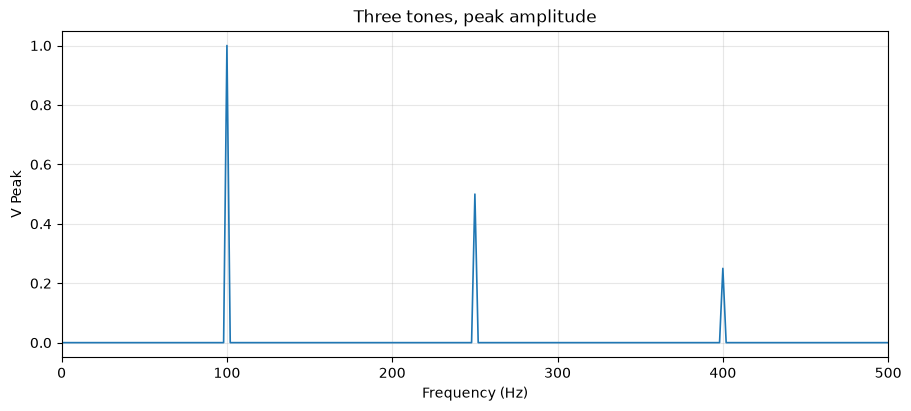

In [5]:
peak = format_spectrum(raw, function_type="Auto Spectrum - (EU Peak)")
ax = spectrum_plot([peak], xlim=(0, 500), title="Three tones, peak amplitude")
for frequency, amplitude in ((100, 1.00), (250, 0.50), (400, 0.25)):
    ax.annotate(f"{amplitude:.2f} V", (frequency, amplitude),
                textcoords="offset points", xytext=(6, -2))

**Why it comes out exact:** the tones sit on whole multiples of the 1 Hz
resolution, so each one's energy lands in a single bin. Real signals do
not oblige — which is section 2.

**Resolution costs averages.** The record is fixed at 8 s, so asking for
finer bins means longer blocks and fewer of them. Overlap buys some back:

In [6]:
print(f"{'df (Hz)':>8} {'block length':>13} {'actual df':>11} "
      f"{'averages @0%':>13} {'@50%':>7}")
for df in (0.5, 1.0, 2.0, 5.0):
    plain = spectral_params(signal.fs, signal.n_samples, df, 0.0)
    lapped = spectral_params(signal.fs, signal.n_samples, df, 0.5)
    print(f"{df:8g} {plain.fft_length:13d} {plain.freq_resolution:11.5f} "
          f"{plain.n_averages:13d} {lapped.n_averages:7d}")
print("\nNote 5 Hz: the block length must be a whole number of samples, so "
      "8192/1638 = 5.00122 Hz\nis the closest achievable. The application "
      "says so in its status bar rather than\nletting you assume otherwise.")

 df (Hz)  block length   actual df  averages @0%    @50%
     0.5         16384     0.50000             4       7
       1          8192     1.00000             8      15
       2          4096     2.00000            16      31
       5          1638     5.00122            40      79

Note 5 Hz: the block length must be a whole number of samples, so 8192/1638 = 5.00122 Hz
is the closest achievable. The application says so in its status bar rather than
letting you assume otherwise.


In [7]:
for frequency, expected in ((100, 1.00), (250, 0.50), (400, 0.25)):
    got = float(peak.y[round(frequency / peak.dt)])
    assert abs(got - expected) < 0.01, f"{frequency} Hz: {got} != {expected}"
print("section 1 OK - amplitudes read 1.00 / 0.50 / 0.25 as the file claims")

section 1 OK - amplitudes read 1.00 / 0.50 / 0.25 as the file claims


## 2. Leakage, and what the window is for

**File:** `05_FFT_Leakage_window_choice.h5` — the same 1 V tone twice, once
at exactly 100.0 Hz and once at 100.5 Hz, half a bin off.

Manual: [Worked example
2](../../docs/manuals/fft-analysis.md#worked-example-2--leakage-and-what-the-window-is-for).

This is the one that catches people out. Nothing is wrong with the signal
and nothing is wrong with the software: a tone that falls between two bins
is split between them, and neither reads its full height. The window
function is the control that trades this error against resolution.

In [8]:
leakage = load("05_FFT_Leakage_window_choice.h5")
ON, OFF = "Tone on bin 100.0 Hz", "Tone off bin 100.5 Hz"


def peak_reading(signal, window):
    """Highest amplitude the spectrum shows for this signal and window."""
    raw = auto_power_spectrums(signal, freq_resolution=1.0, window=window)
    return format_spectrum(raw, function_type="Auto Spectrum - (EU Peak)")


print(f"{'window':18} {'on bin':>9} {'off bin':>9} {'error':>9} "
      f"{'ENBW':>7} {'CG':>7}")
for window in ("rectangular", "hamming", "hanning", "blackman_harris",
               "low_sidelobe", "bh_7term", "flat_top"):
    on = float(peak_reading(leakage[ON], window).y.max())
    off = float(peak_reading(leakage[OFF], window).y.max())
    props = W.props(W.window(window, 8192))
    print(f"{window:18} {on:9.5f} {off:9.5f} {100 * (off - 1):8.2f}% "
          f"{props.eq_noise_bw:7.4f} {props.coherent_gain:7.4f}")

window                on bin   off bin     error    ENBW      CG
rectangular          1.00000   0.63820   -36.18%  1.0000  1.0000
hamming              1.00000   0.81762   -18.24%  1.3628  0.5400
hanning              1.00000   0.84883   -15.12%  1.5000  0.5000
blackman_harris      1.00000   0.87816   -12.18%  1.7085  0.4232
low_sidelobe         1.00000   0.92469    -7.53%  2.2154  0.3232
bh_7term             1.00000   0.94573    -5.43%  2.6319  0.2711
flat_top             1.00000   0.99888    -0.11%  3.7702  0.2156


Read that as the trade it is: Rectangle is best for resolution and worst
for amplitude, Flat Top the reverse, Hanning in the middle. Here are the
two extremes drawn on the same tones — note the flat-topped peak, which is
where the window gets its name and its accuracy.

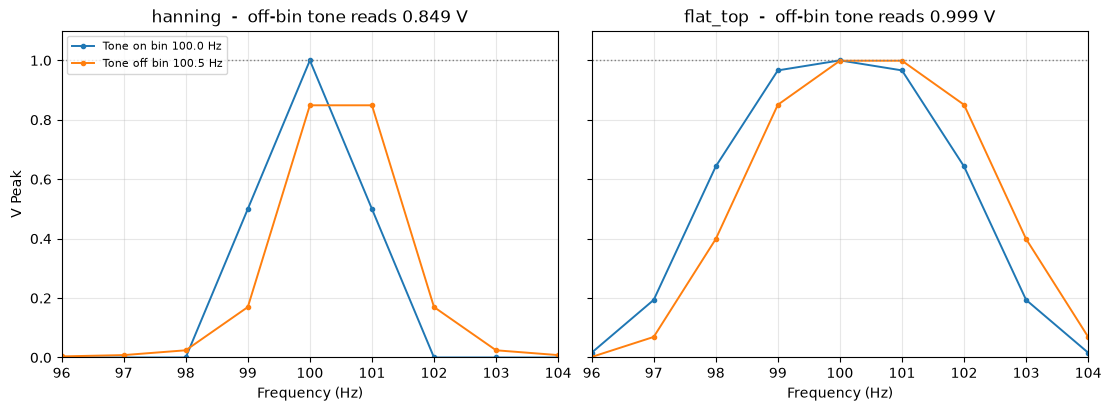

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True,
                         constrained_layout=True)
for ax, window in zip(axes, ("hanning", "flat_top"), strict=True):
    for name in (ON, OFF):
        shown = peak_reading(leakage[name], window)
        ax.plot(shown.t, shown.y, lw=1.4, marker="o", ms=3, label=name)
    ax.set(xlim=(96, 104), ylim=(0, 1.1), xlabel="Frequency (Hz)",
           title=f"{window}  -  off-bin tone reads "
                 f"{float(peak_reading(leakage[OFF], window).y.max()):.3f} V")
    ax.axhline(1.0, color="grey", ls=":", lw=1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("V Peak")
axes[0].legend(loc="upper left", fontsize=8)
plt.show()

**Choosing one:** *Flat Top* to measure the level of a tone. *Hanning* to
separate tones that are close together, and for broadband noise — noise
fills every bin, so scalloping never arises. *Rectangle* for transients
that start and stop inside the block, where there is no edge discontinuity
to taper away and a window would throw away the start of the event.

In [10]:
hanning_off = float(peak_reading(leakage[OFF], "hanning").y.max())
flattop_off = float(peak_reading(leakage[OFF], "flat_top").y.max())
assert abs(hanning_off - 0.849) < 0.01, hanning_off
assert abs(flattop_off - 1.000) < 0.01, flattop_off
print(f"section 2 OK - Hanning under-reads by {100 * (1 - hanning_off):.1f} %, "
      f"Flat Top by {100 * (1 - flattop_off):.1f} %")

section 2 OK - Hanning under-reads by 15.1 %, Flat Top by 0.1 %


## 3. Decibels and the 94 dB calibrator

**File:** `06_FFT_SPL_94dB_calibration.h5` — a 1 kHz tone at exactly 1 Pa
RMS, the same tone at 0.1 Pa, and pink noise at 1 Pa RMS overall.

Manual: [Worked example
3](../../docs/manuals/fft-analysis.md#worked-example-3--decibels-and-the-94-db-calibrator).

1 Pa RMS is what an acoustic calibrator produces, and referred to 20 µPa
it is the familiar "94 dB".

In [11]:
acoustic = load("06_FFT_SPL_94dB_calibration.h5")
CALIBRATOR, QUIETER = "1 Pa RMS at 1 kHz (94 dB)", "0.1 Pa RMS at 1 kHz (74 dB)"

spl = {}
for name in (CALIBRATOR, QUIETER):
    raw = auto_power_spectrums(acoustic[name], freq_resolution=1.0,
                               window="flat_top")          # a calibration
    spl[name] = format_spectrum(
        raw, function_type="Auto Spectrum - (EU RMS)",
        display_option="dB - Sound SPL (ref 20E-6 Pa)")
    print(f"{name:32} peak {float(spl[name].y.max()):7.3f} {spl[name].y_unit}")

print(f"\nexactly: 20*log10(1 / 20e-6) = {20 * np.log10(1 / 20e-6):.4f} dB")
print("94 dB is the round number, not the exact one - calibrators are sold "
      "as '94 dB'\nfor the same reason a 1 kOhm resistor is not 1000.0 Ohm. "
      "SPWB does not round it\nfor you, which is what you want from an "
      "instrument.")

1 Pa RMS at 1 kHz (94 dB)        peak  93.979 dB ref 20E-6 Pa
0.1 Pa RMS at 1 kHz (74 dB)      peak  73.979 dB ref 20E-6 Pa

exactly: 20*log10(1 / 20e-6) = 93.9794 dB
94 dB is the round number, not the exact one - calibrators are sold as '94 dB'
for the same reason a 1 kOhm resistor is not 1000.0 Ohm. SPWB does not round it
for you, which is what you want from an instrument.


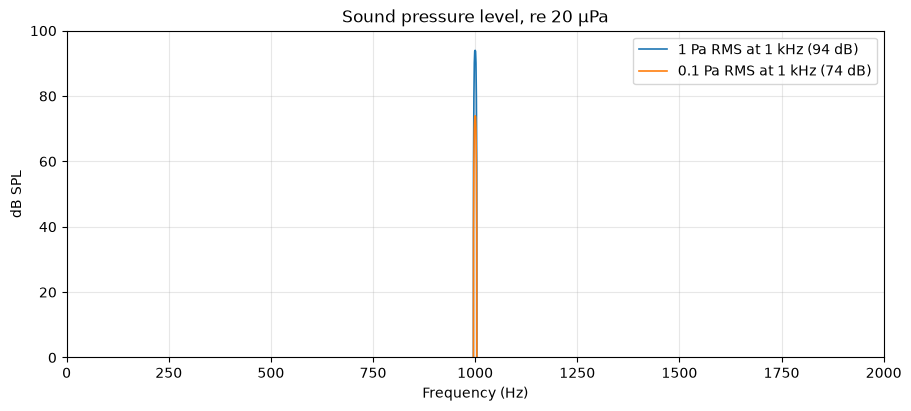

<Axes: title={'center': 'Sound pressure level, re 20 µPa'}, xlabel='Frequency (Hz)', ylabel='dB SPL'>

In [12]:
spectrum_plot(list(spl.values()), xlim=(0, 2000), ylim=(0, 100),
              title="Sound pressure level, re 20 µPa", ylabel="dB SPL")

**Checking it against the time domain.** A band sum over the peak should
equal the RMS the Time Processing window reports for the whole signal —
two completely different paths to the same number. That agreement is the
check that windowing, averaging and bandwidth normalisation are all right.

In [13]:
raw_cal = auto_power_spectrums(acoustic[CALIBRATOR], freq_resolution=1.0,
                               window="flat_top")
print(f"band 900-1100 Hz RMS : {band_rms(raw_cal, 900, 1100):.6f} Pa")
print(f"time-domain RMS      : {signal_statistics(acoustic[CALIBRATOR]).rms:.6f} Pa")

band 900-1100 Hz RMS : 1.000000 Pa
time-domain RMS      : 1.000000 Pa


**Where this gets harder: broadband noise.** The tallest single bin of the
pink-noise signal means nothing on its own, because noise spreads its
energy over every bin and the height of any one bin depends on how wide
you made the bins. Only a band sum is meaningful — and even that is a
*random quantity*. Pink noise puts most of its power in the lowest few
bins, which are averaged over the fewest blocks, so the total wanders:

In [14]:
pink = acoustic["Pink-ish noise 1 Pa RMS"]
print(f"true RMS (time domain): {signal_statistics(pink).rms:.5f} Pa\n")
print(f"{'df (Hz)':>8} {'averages':>9} {'total RMS (Pa)':>15}")
totals = {}
for df in (0.25, 0.5, 1.0, 2.0, 4.0, 8.0):
    raw_pink = auto_power_spectrums(pink, freq_resolution=df,
                                    window="hanning")
    totals[df] = band_rms(raw_pink, 0, pink.fs / 2)
    print(f"{df:8g} {raw_pink.attributes['FFT_Nb_Averages']:9d} "
          f"{totals[df]:15.5f}")
print("\nThat scatter is not an error in the sum - it is the estimate itself "
      "being noisy.\nThis is the oldest lesson in spectral estimation: a "
      "spectrum of a random signal\nis a random quantity, and it needs "
      "averaging before it means anything.")

true RMS (time domain): 1.00000 Pa

 df (Hz)  averages  total RMS (Pa)
    0.25         2         0.98185
     0.5         4         1.07833
       1         8         0.93604
       2        16         1.01962
       4        32         1.01895
       8        64         0.98148

That scatter is not an error in the sum - it is the estimate itself being noisy.
This is the oldest lesson in spectral estimation: a spectrum of a random signal
is a random quantity, and it needs averaging before it means anything.


In [15]:
assert abs(float(spl[CALIBRATOR].y.max()) - 93.98) < 0.05
assert abs(float(spl[QUIETER].y.max()) - 73.98) < 0.05
assert abs(band_rms(raw_cal, 900, 1100) - 1.0) < 1e-4
print("section 3 OK - 93.98 dB, the quieter tone exactly 20 dB down, "
      "band RMS 1.000 Pa")

section 3 OK - 93.98 dB, the quieter tone exactly 20 dB down, band RMS 1.000 Pa


## 4. A-weighting

**File:** `07_FFT_A_weighting_octave_tones.h5` — ten tones of exactly equal
amplitude at the octave centres from 31.5 Hz to 16 kHz.

Manual: [Worked example
4](../../docs/manuals/fft-analysis.md#worked-example-4--a-weighting).

Because the tones are equal, whatever shape the weighted plot takes *is*
the weighting curve. A-weighting is the inverse of Fletcher and Munson's
40-phon equal-loudness contour, standardised in 1936 and still in use.

In [16]:
octaves = load("07_FFT_A_weighting_octave_tones.h5")["Octave tones, equal 1.0 Vpk"]
raw_oct = auto_power_spectrums(octaves, freq_resolution=2.0, window="flat_top")

plain = format_spectrum(raw_oct, function_type="Auto Spectrum - (EU RMS)",
                        display_option="dB - NO reference value")
weighted = format_spectrum(raw_oct, function_type="Auto Spectrum - (EU RMS)",
                           display_option="dB - NO reference value",
                           weighting="A-weighting")

CENTRES = (31.5, 63, 125, 250, 500, 1000, 2000, 4000, 8000, 16000)
IEC_61672 = (-39.4, -26.2, -16.1, -8.6, -3.2, 0.0, 1.2, 1.0, -1.1, -6.6)

print(f"{'tone':>8} {'unweighted':>12} {'A-weighted':>12} {'applied':>9} "
      f"{'IEC table':>11}")
applied = []
for frequency, tabulated in zip(CENTRES, IEC_61672, strict=True):
    k = round(frequency / plain.dt)
    delta = float(weighted.y[k] - plain.y[k])
    applied.append(delta)
    print(f"{frequency:8g} {float(plain.y[k]):12.2f} {float(weighted.y[k]):12.2f} "
          f"{delta:9.2f} {tabulated:11.1f}")

    tone   unweighted   A-weighted   applied   IEC table
    31.5        -3.01       -42.19    -39.19       -39.4
      63        -3.02       -28.98    -25.96       -26.2
     125        -3.02       -19.31    -16.29       -16.1
     250        -3.01       -11.69     -8.67        -8.6
     500        -3.01        -6.26     -3.25        -3.2
    1000        -3.01        -3.01      0.00         0.0
    2000        -3.01        -1.81      1.20         1.2
    4000        -3.01        -2.05      0.96         1.0
    8000        -3.01        -4.15     -1.14        -1.1
   16000        -3.01        -9.71     -6.70        -6.6


Every tone sits at -3.01 dB unweighted, because a 1.0 V amplitude sine has
an RMS of 0.707. Weighted, they land on the continuous curve — which the
plot below draws underneath them, straight from `a_weighting()`:

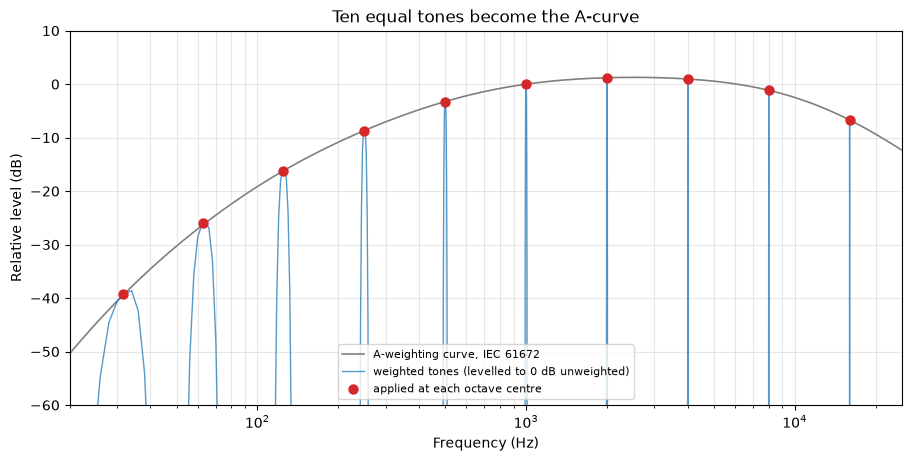

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
smooth = np.logspace(np.log10(10), np.log10(25000), 800)
ax.semilogx(smooth, a_weighting(smooth), lw=1.2, color="grey",
            label="A-weighting curve, IEC 61672")
ax.semilogx(weighted.t[1:], weighted.y[1:] + 3.01, lw=1.0, alpha=0.75,
            label="weighted tones (levelled to 0 dB unweighted)")
ax.scatter(CENTRES, applied, s=42, zorder=5, color="tab:red",
           label="applied at each octave centre")
ax.set(xlabel="Frequency (Hz)", ylabel="Relative level (dB)", ylim=(-60, 10),
       xlim=(20, 25000), title="Ten equal tones become the A-curve")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="lower center")
plt.show()

**On the last column of the table.** SPWB evaluates the analytic pole-zero
formula that *defines* A-weighting, while the standard also publishes
rounded values at nominal frequencies. The two differ by up to 0.25 dB —
well inside the ±1 dB that IEC 61672 allows a class 1 instrument here, and
it is the formula that is normative.

In [18]:
for frequency, delta, tabulated in zip(CENTRES, applied, IEC_61672, strict=True):
    assert abs(delta - tabulated) < 0.6, f"{frequency} Hz: {delta} vs {tabulated}"
assert abs(applied[CENTRES.index(1000)]) < 0.01, "1 kHz must be the anchor"
print("section 4 OK - the curve matches IEC 61672 within 0.25 dB, "
      "and 1 kHz is exactly 0 dB")

section 4 OK - the curve matches IEC 61672 within 0.25 dB, and 1 kHz is exactly 0 dB


## 5. Harmonics, THD and energy bands

**File:** `08_FFT_Harmonics_THD.h5` — a 100 Hz fundamental at 1.0 V with
harmonics at 10 %, 5 % and 1 %, giving a total harmonic distortion of
exactly 11.22 %.

Manual: [Worked example
5](../../docs/manuals/fft-analysis.md#worked-example-5--harmonics-thd-and-the-energy-band-tab).

Displaying peak amplitude in plain dB puts the fundamental on 0 dB, which
makes every other peak a distortion figure you can read directly.

In [19]:
distorted = load("08_FFT_Harmonics_THD.h5")["100 Hz + harmonics (THD 11.2 %)"]
raw_thd = auto_power_spectrums(distorted, freq_resolution=1.0, window="hanning")
amplitude = format_spectrum(raw_thd, function_type="Auto Spectrum - (EU Peak)")

fundamental = float(amplitude.y[round(100 / amplitude.dt)])
print(f"{'component':>12} {'frequency':>10} {'amplitude':>11} {'relative':>10}")
harmonics = []
for order in (1, 2, 3, 4):
    level = float(amplitude.y[round(100 * order / amplitude.dt)])
    harmonics.append(level)
    print(f"{'fundamental' if order == 1 else f'harmonic {order}':>12} "
          f"{100 * order:8g} Hz {level:11.5f} "
          f"{20 * np.log10(level / fundamental):9.2f} dB")

   component  frequency   amplitude   relative
 fundamental      100 Hz     1.00000      0.00 dB
  harmonic 2      200 Hz     0.10000    -20.00 dB
  harmonic 3      300 Hz     0.05000    -26.02 dB
  harmonic 4      400 Hz     0.01000    -40.00 dB


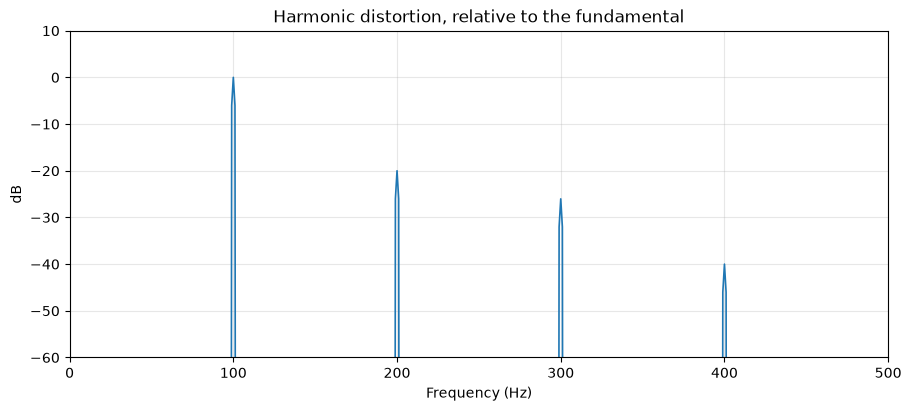

In [20]:
decibels = format_spectrum(raw_thd, function_type="Auto Spectrum - (EU Peak)",
                           display_option="dB - NO reference value")
ax = spectrum_plot([decibels], xlim=(0, 500), ylim=(-60, 10),
                   title="Harmonic distortion, relative to the fundamental",
                   ylabel="dB")
for order, level in enumerate(harmonics, start=1):
    ax.annotate(f"H{order}", (100 * order, 20 * np.log10(level / fundamental)),
                textcoords="offset points", xytext=(5, 4))

**THD as a single number.** Distortion is the RMS of all the harmonics
divided by the fundamental — exactly the kind of sum the **Energy Band**
tab does. Two routes, one answer:

In [21]:
from_peaks = np.sqrt(sum(h ** 2 for h in harmonics[1:])) / fundamental
in_harmonics = band_rms(raw_thd, 150, 450)      # H2..H4, above the fundamental
in_fundamental = band_rms(raw_thd, 50, 150)
from_bands = in_harmonics / in_fundamental

print(f"harmonic peaks     : {100 * from_peaks:.3f} %")
print(f"band 150-450 Hz    : {in_harmonics:.6f} V rms")
print(f"band  50-150 Hz    : {in_fundamental:.6f} V rms")
print(f"their ratio        : {100 * from_bands:.3f} %   "
      f"= {20 * np.log10(from_bands):.2f} dB")

harmonic peaks     : 11.225 %
band 150-450 Hz    : 0.079373 V rms
band  50-150 Hz    : 0.707107 V rms
their ratio        : 11.225 %   = -19.00 dB


**Parseval's theorem, as a sanity check on the whole chain.** Sum the
entire spectrum and you must get the time-domain RMS back — windowing,
averaging and bandwidth normalisation all have to be right for this to
hold:

In [22]:
print(f"full-band energy   : {band_rms(raw_thd, 0, distorted.fs / 2):.9f} V")
print(f"time-domain RMS    : {signal_statistics(distorted).rms:.9f} V")

full-band energy   : 0.711547609 V
time-domain RMS    : 0.711547609 V


**One trap worth meeting once.** Band edges include their endpoint, so an
edge placed *on* a peak counts that peak in both bands. Splitting the
1 kHz calibrator tone at exactly 1000 Hz gives nonsense; splitting either
side of it does not:

In [23]:
low, high = band_rms(raw_cal, 0, 1000), band_rms(raw_cal, 1000, 25000)
print(f"split AT 1000 Hz : {low:.4f} + {high:.4f} Pa  -> "
      f"{low**2 + high**2:.4f} Pa² of a 1.0000 Pa² signal  (the peak is "
      f"counted twice)")

low, centre, high = (band_rms(raw_cal, 0, 999), band_rms(raw_cal, 1000, 1000),
                     band_rms(raw_cal, 1001, 25000))
print(f"split either side: {low:.4f} + {centre:.4f} + {high:.4f} Pa -> "
      f"{low**2 + centre**2 + high**2:.4f} Pa²  (exact)")
print("\nAlways put band edges in a quiet place.")

split AT 1000 Hz : 0.7954 + 0.7954 Pa  -> 1.2652 Pa² of a 1.0000 Pa² signal  (the peak is counted twice)
split either side: 0.6061 + 0.5150 + 0.6061 Pa -> 1.0000 Pa²  (exact)

Always put band edges in a quiet place.


In [24]:
assert abs(100 * from_peaks - 11.22) < 0.05, from_peaks
assert abs(from_peaks - from_bands) < 1e-6, "the two routes must agree"
assert abs(band_rms(raw_thd, 0, distorted.fs / 2)
           - signal_statistics(distorted).rms) < 1e-9, "Parseval"
print(f"section 5 OK - THD {100 * from_bands:.2f} % by both routes, "
      "and Parseval holds to 1e-9")

section 5 OK - THD 11.22 % by both routes, and Parseval holds to 1e-9


## Where to go next

* The [FFT Analysis manual](../../docs/manuals/fft-analysis.md) — the same
  five examples driven through the application, plus the history of where
  all of this came from and a reference table for every control.
* [`examples/01_spectrum_from_a_file.py`](../01_spectrum_from_a_file.py) —
  the same workflow on your own recording, including saving results back
  out to TDMS.
* `python tools/verify_demo_data.py` — the 27 assertions that keep the
  demo datasets honest, of which this notebook re-checks a dozen.

To use your own data, replace the `load(...)` calls with
`read_tdms("run.tdms")`, `read_wave("take1.wav")` or
`read_hdf5("measurement.h5")`. Everything downstream is unchanged.

---

## Support This Work

If anything here was useful to you, please consider contributing.
SPWB is free and open source, and always will be — donations are
what let Charette AI Group keep maintaining it and open-sourcing
its other tools.

<p align="center">
  <a href="https://www.paypal.com/donate/?hosted_button_id=FEM4WLD7LHY36">
      <img src="https://www.paypalobjects.com/en_US/i/btn/btn_donateCC_LG.gif" alt="Donate with PayPal">
  </a>
</p>